In [ ]:
# Check GPU
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


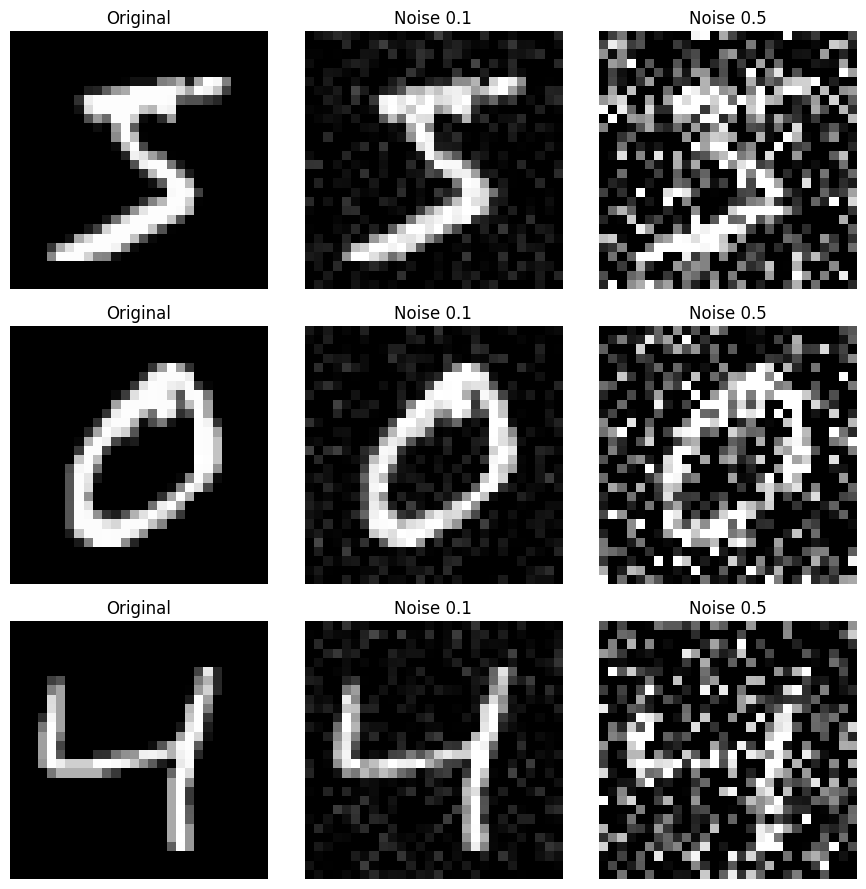

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
  # Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
  plt.title("Original")
  plt.axis("off")
  # Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.1")
  plt.axis('off')
  # High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.5")
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
Input = mnist.load_data()

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [ ]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.
  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [ ]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1558 - val_loss: 0.1130
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.1091 - val_loss: 0.1046
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1040 - val_loss: 0.1014
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1013 - val_loss: 0.0996
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0996 - val_loss: 0.0981
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0984 - val_loss: 0.0973
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0977 - val_loss: 0.0964
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0969 - val_loss: 0.0959
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0964 - val_loss: 0.0955
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0958 - val_loss: 0.0951


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


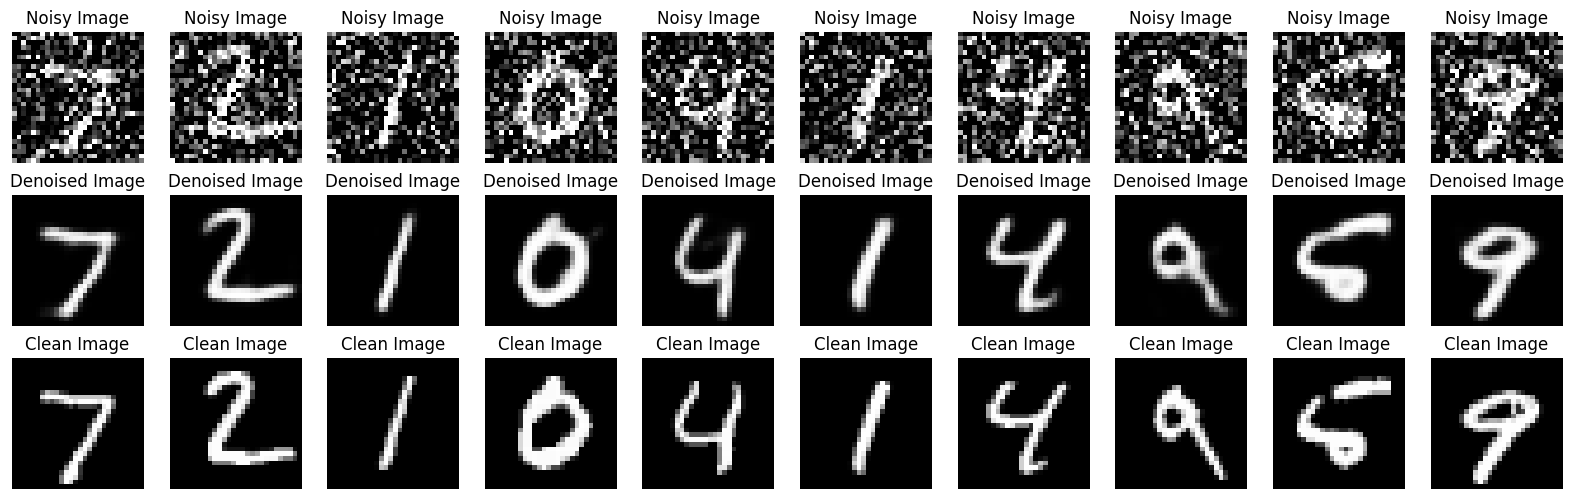

In [ ]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)
# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Plot noisy images
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Image")
    plt.axis('off')
    # Plot denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Image")
    plt.axis('off')
    # Plot clean images
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()
# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
dataset_path = '/content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset'

In [ ]:
IMG_SIZE = 32
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def load_devnagari_dataset(root_path, img_size=32):
    images = []
    labels = []
    class_names = []

    # Collect all leaf folders that contain image files
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp')
    leaf_dirs = []

    for dirpath, dirnames, filenames in os.walk(root_path):
        image_files = [f for f in filenames if f.lower().endswith(valid_ext)]
        if len(image_files) > 0:
            leaf_dirs.append(dirpath)

    leaf_dirs = sorted(leaf_dirs)

    # Map each leaf folder name to label
    for folder in leaf_dirs:
        class_name = os.path.basename(folder)
        if class_name not in class_names:
            class_names.append(class_name)

    class_names = sorted(class_names)
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    for folder in leaf_dirs:
        class_name = os.path.basename(folder)
        label = class_to_idx[class_name]

        for file_name in os.listdir(folder):
            if file_name.lower().endswith(valid_ext):
                img_path = os.path.join(folder, file_name)

                try:
                    img = Image.open(img_path).convert('L')  # grayscale
                    img = img.resize((img_size, img_size))
                    img = np.array(img, dtype=np.float32) / 255.0  # normalize to [0,1]
                    images.append(img)
                    labels.append(label)
                except Exception as e:
                    print(f"Skipped {img_path}: {e}")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)

    # Add channel dimension -> (N, H, W, 1)
    images = np.expand_dims(images, axis=-1)

    return images, labels, class_names

X, y, class_names = load_devnagari_dataset(dataset_path, img_size=IMG_SIZE)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Number of classes:", len(class_names))
print("Class names:", class_names)

Skipped /content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset/Train/digit_0/89463.png: cannot identify image file '/content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset/Train/digit_0/89463.png'
Dataset shape: (19999, 32, 32, 1)
Labels shape: (19999,)
Number of classes: 10
Class names: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (15999, 32, 32, 1)
X_val shape: (4000, 32, 32, 1)


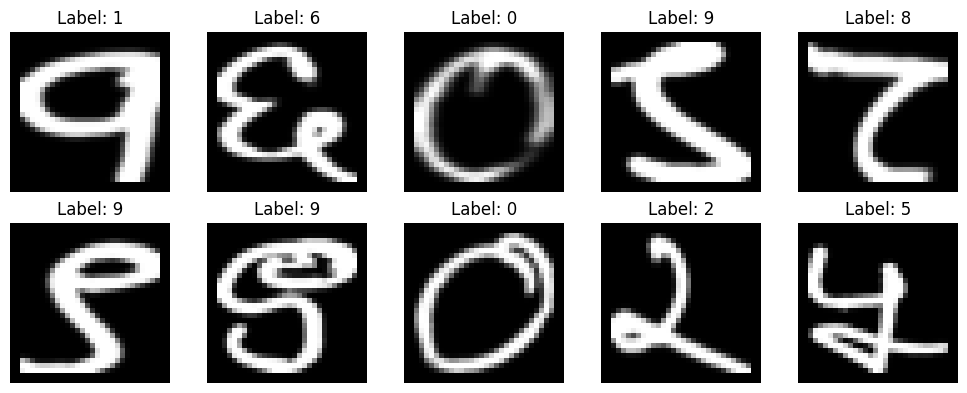

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
noise_factor = 0.4

X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_val_noisy = X_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_val.shape)

# Clip pixel values to keep them in [0,1]
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_val_noisy = np.clip(X_val_noisy, 0.0, 1.0)

print("Noisy train shape:", X_train_noisy.shape)
print("Noisy val shape:", X_val_noisy.shape)

Noisy train shape: (15999, 32, 32, 1)
Noisy val shape: (4000, 32, 32, 1)


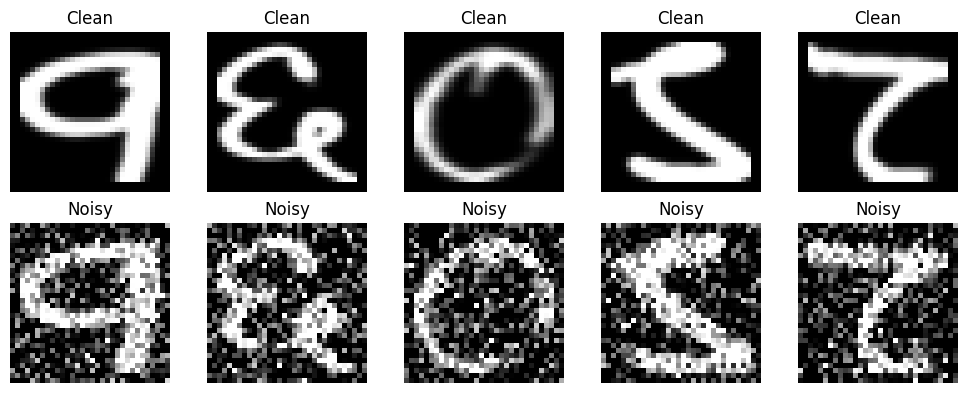

In [ ]:
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Clean image
    plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    # Noisy image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_train_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def build_denoising_autoencoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

    return autoencoder

autoencoder = build_denoising_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 1))
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(X_val_noisy, X_val)
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 0.3648 - val_loss: 0.2294
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2028 - val_loss: 0.1866
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1760 - val_loss: 0.1753
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1651 - val_loss: 0.1624
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1576 - val_loss: 0.1549
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1530 - val_loss: 0.1530
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1498 - val_loss: 0.1489
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1472 - val_loss: 0.1466
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1453 - val_loss: 0.1446
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1436 - val_loss: 0.1432
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1423 - val_loss: 0.1419
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━

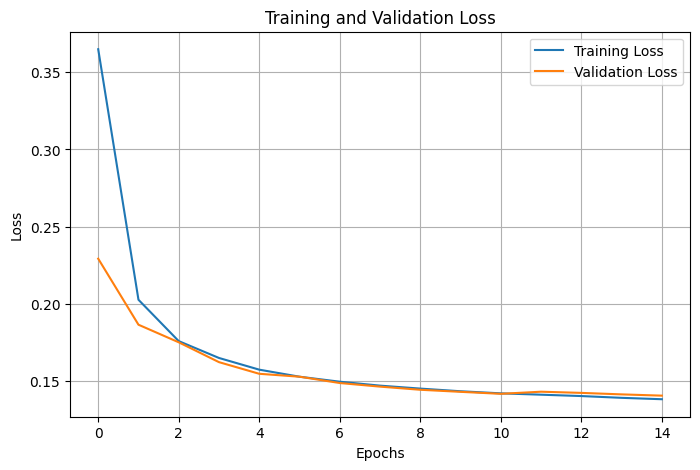

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
denoised_images = autoencoder.predict(X_val_noisy)
print("Denoised images shape:", denoised_images.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Denoised images shape: (4000, 32, 32, 1)


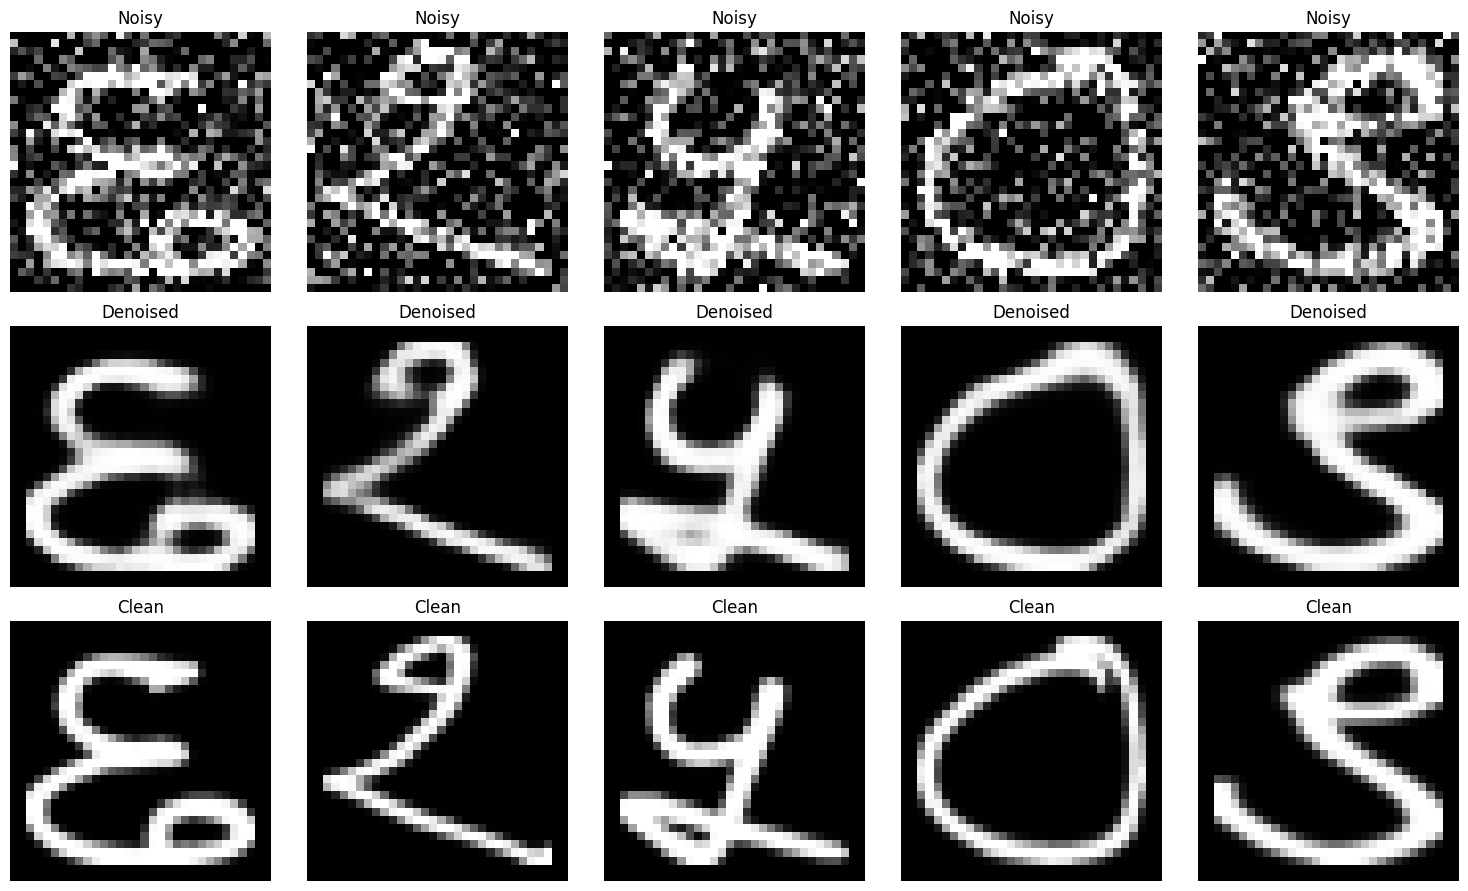

In [ ]:
def plot_denoising_results(noisy_images, denoised_images, clean_images, n=5):
    plt.figure(figsize=(15, 9))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].squeeze(), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Clean
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].squeeze(), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_denoising_results(X_val_noisy, denoised_images, X_val, n=5)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


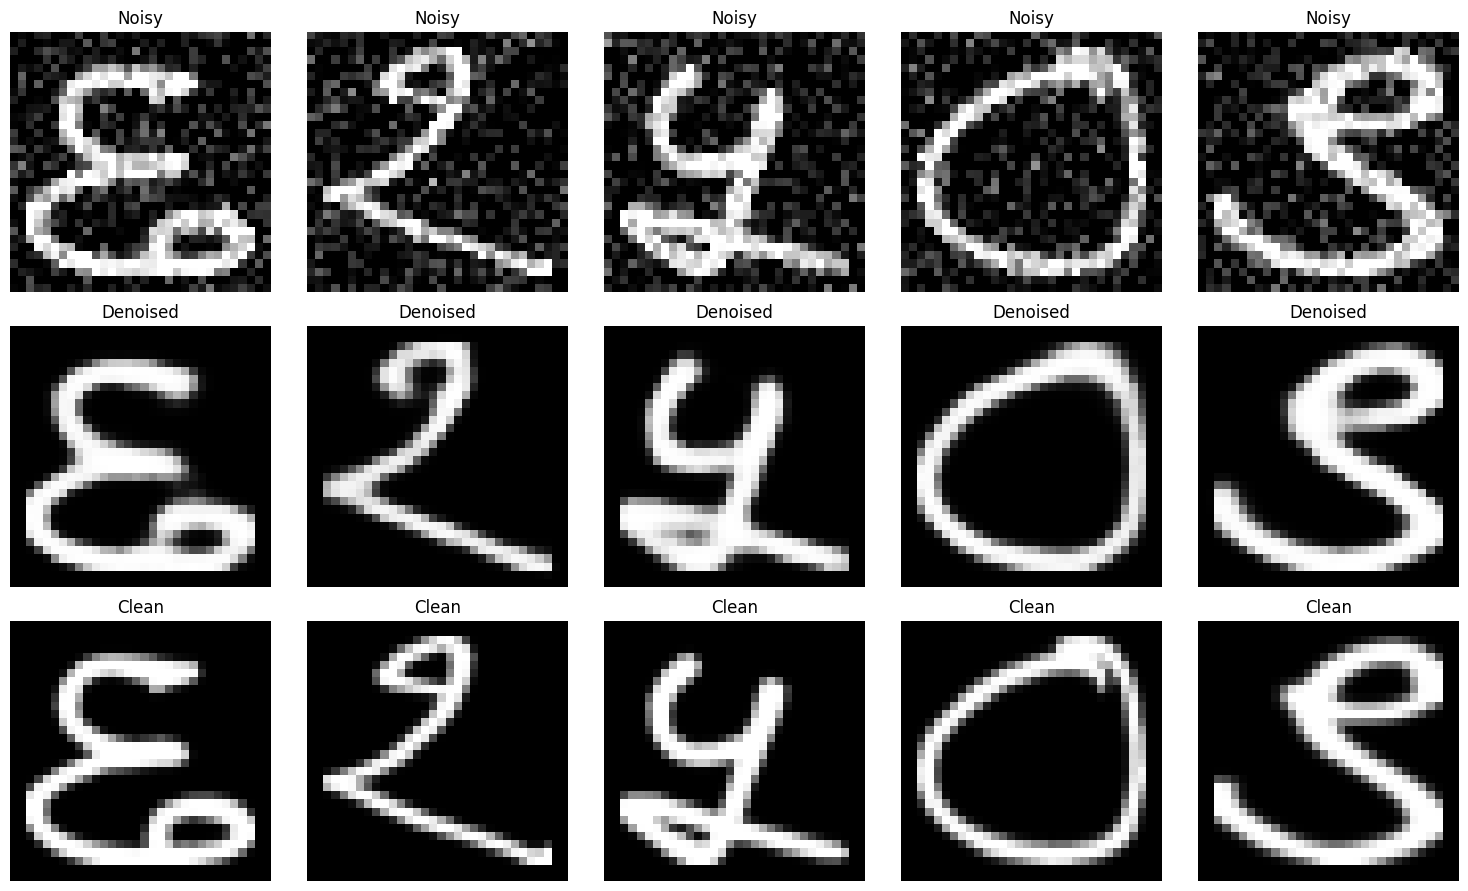

In [ ]:
new_noise_factor = 0.2

X_val_noisy_2 = X_val + new_noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_val.shape)
X_val_noisy_2 = np.clip(X_val_noisy_2, 0.0, 1.0)

denoised_images_2 = autoencoder.predict(X_val_noisy_2)

plot_denoising_results(X_val_noisy_2, denoised_images_2, X_val, n=5)